In [4]:
%matplotlib inline
from ultralytics import YOLO
import matplotlib.pyplot as plt

import random
import shutil
from pathlib import Path
from collections import Counter

# Fucntions

In [9]:
def get_samples(img_dir, lbl_dir):
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    samples = []
    for img_path in img_dir.iterdir():
        if not img_path.is_file() or img_path.suffix.lower() not in valid_exts:
            continue
        label_path = lbl_dir / f"{img_path.stem}.txt"
        if label_path.is_file():
            txt = label_path.read_text(encoding="utf-8", errors="ignore").strip()
            if txt:
                samples.append((img_path, label_path))

    print(f"Valid labeled samples: {len(samples)}")
    if not samples:
        raise RuntimeError("No labeled samples found")
    return samples

def split_samples(samples, TRAIN_RATIO, VAL_RATIO):
    random.shuffle(samples) #shuffle the samples
    n = len(samples)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    train_samples = samples[:n_train]
    val_samples = samples[n_train : n_train + n_val]
    test_samples = samples[n_train + n_val :]
    return train_samples, val_samples, test_samples


def copy_split(split_name, split_samples, dest_path):
    for img_path, lbl_path in split_samples:
        shutil.copy2(img_path, dest_path / split_name / "images" / img_path.name)
        shutil.copy2(lbl_path, dest_path / split_name / "labels" / lbl_path.name)

# Cat Data prep and model develpment

In [15]:
# SOURCE_DATASET: flat YOLO images/ + labels/ under lisa-stop-only.
# YOLO_DATASET: train/val/test copies + dataset.yaml at project root (rebuilt when you rerun the split cell).
SEED = 42
random.seed(SEED)

PROJECT_ROOT = Path.cwd().resolve()
cat_source = PROJECT_ROOT / "lisa-stop-only" #labeld data and images 
cat_split = PROJECT_ROOT / "cat_stop_split" #split data into train, val and test
cat_Data_YAML = cat_split / "dataset.yaml" #dataset.yaml file
MODEL_NAME = "yolo11s.pt"
RUNS_DETECT = PROJECT_ROOT / "runs" / "detect"  # Ultralytics train/val logs (absolute)

TRAIN_RATIO = 0.75
VAL_RATIO = 0.10
TEST_RATIO = 1 -TRAIN_RATIO - VAL_RATIO

img_dir = cat_source / "images"
lbl_dir = cat_source / "labels"

if not img_dir.is_dir() or not lbl_dir.is_dir():
    raise FileNotFoundError("Expected lisa-stop-only/images and lisa-stop-only/labels")

samples = get_samples(img_dir, lbl_dir)
train_samples, val_samples, test_samples = split_samples(samples, TRAIN_RATIO, VAL_RATIO)

print(f"train={len(train_samples)}, val={len(val_samples)}, test={len(test_samples)}")

if cat_split.exists():
    shutil.rmtree(cat_split)

for split in ("train", "val", "test"): #make the directory for the split of the data into train, val and test
    (cat_split / split / "images").mkdir(parents=True, exist_ok=True)
    (cat_split / split / "labels").mkdir(parents=True, exist_ok=True)

for name, part in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    copy_split(name, part, cat_split)

dataset_yaml = f"""path: {cat_split.resolve()}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['stop']
"""

cat_Data_YAML.write_text(dataset_yaml.strip() + "\n", encoding="utf-8")
print("Wrote", cat_Data_YAML.resolve())
for split in ("train", "val", "test"):
    n_img = len(list((cat_split / split / "images").iterdir()))
    n_lbl = len(list((cat_split / split / "labels").glob("*.txt")))
    print(f"{split}: images={n_img}, labels={n_lbl}")

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9
print("Project root:", PROJECT_ROOT)
print("Source:", cat_source)
print("Split output:", cat_split)
print("Model:", MODEL_NAME)
print("Runs dir:", RUNS_DETECT)


Valid labeled samples: 1643
train=1232, val=164, test=247
Wrote /research/bdaqiq/AV-ADAS_detection/cat_stop_split/dataset.yaml
train: images=1232, labels=1232
val: images=164, labels=164
test: images=247, labels=247
Project root: /research/bdaqiq/AV-ADAS_detection
Source: /research/bdaqiq/AV-ADAS_detection/lisa-stop-only
Split output: /research/bdaqiq/AV-ADAS_detection/cat_stop_split
Model: yolo11s.pt
Runs dir: /research/bdaqiq/AV-ADAS_detection/runs/detect


Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1613.8±590.7 MB/s, size: 67.2 KB)
val: Scanning /research/bdaqiq/AV-ADAS_detection/cat_stop_split/test/labels... 247 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 247/247 1.6Kit/s 0.2s<0.2s
val: New cache created: /research/bdaqiq/AV-ADAS_detection/cat_stop_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 7.0it/s 2.3s<0.2s
                   all        247        309    0.00763        0.1    0.00463    0.00202
                person        247        309    0.00763        0.1    0.00463    0.00202
Speed: 1.2ms preprocess, 1.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /research/bdaqiq/CSCI611_Basira_Daqiq/runs/detect/val8
Pretrained yolo11s.

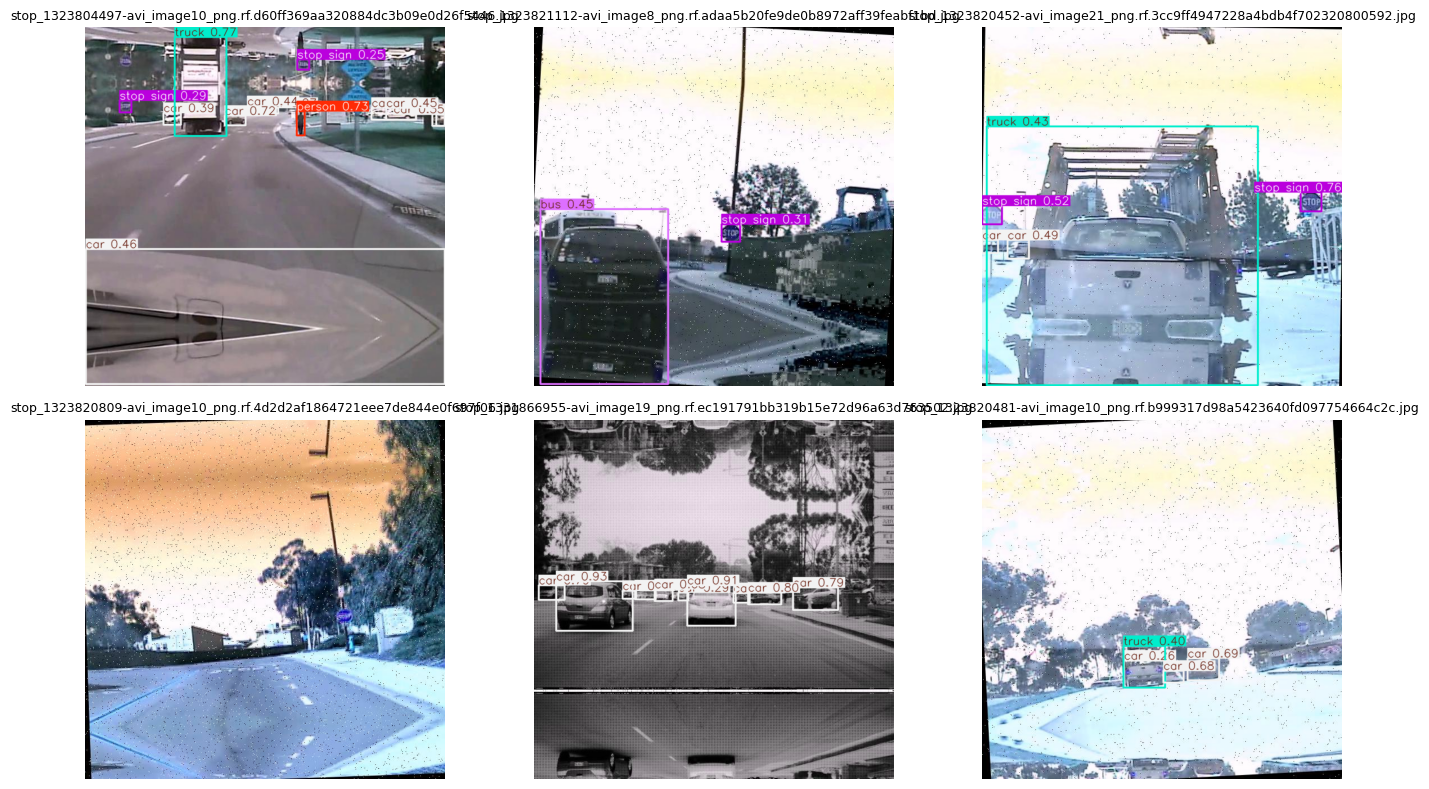

In [12]:
# Evaluate pre-trained YOLO11s on test split before fine-tuning
pretrained_model = YOLO(MODEL_NAME)
pre_val = pretrained_model.val(
    data=str(cat_Data_YAML),
    split="test",
    project=str(RUNS_DETECT),
    name="pretrained_val_test",
)
print(f"Pretrained {MODEL_NAME} -> mAP50={pre_val.box.map50:.4f}, mAP50-95={pre_val.box.map:.4f}")

# Quick visual check on 6 random test images
sample_test = list((cat_split / "test" / "images").glob("*"))
random.shuffle(sample_test)
sample_test = sample_test[:6]

if sample_test:
    preds = pretrained_model([str(p) for p in sample_test])
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(preds):
            ax.imshow(preds[i].plot())
            ax.set_title(sample_test[i].name, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
# Fine-tune YOLO11s baseline on LISA stop-only split
model_train = YOLO(MODEL_NAME)
results_train = model_train.train(
    data=str(cat_Data_YAML),
    epochs=30,
    imgsz=960,
    batch=8,
    patience=12,
    project=str(RUNS_DETECT),
    name="lisa_stop_yolo11s_fineTuned",
)

baseline_best = Path(results_train.save_dir) / "weights" / "best.pt"
print("Baseline best:", baseline_best)

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/research/bdaqiq/AV-ADAS_detection/cat_stop_split/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mos


image 1/1 /research/bdaqiq/AV-ADAS_detection/cat_stop_split/test/images/stop_1323819291-avi_image7_png.rf.cf4bafdb3b81f66fad56963f9322096c.jpg: 640x640 1 stop sign, 10.8ms
Speed: 1.7ms preprocess, 10.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /research/bdaqiq/AV-ADAS_detection/cat_stop_split/test/images/stop_1323819291-avi_image7_png.rf.cf4bafdb3b81f66fad56963f9322096c.jpg: 960x960 1 stop, 10.8ms
Speed: 7.9ms preprocess, 10.8ms inference, 1.5ms postprocess per image at shape (1, 3, 960, 960)

image 1/1 /research/bdaqiq/AV-ADAS_detection/cat_stop_split/test/images/stop_1323896809-avi_image6_png.rf.e22fb1c9302cdea383ae0191803d99a6.jpg: 640x640 4 cars, 11.0ms
Speed: 2.8ms preprocess, 11.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /research/bdaqiq/AV-ADAS_detection/cat_stop_split/test/images/stop_1323896809-avi_image6_png.rf.e22fb1c9302cdea383ae0191803d99a6.jpg: 960x960 2 stops, 11.2ms
Speed: 4.9ms preprocess, 11.2ms

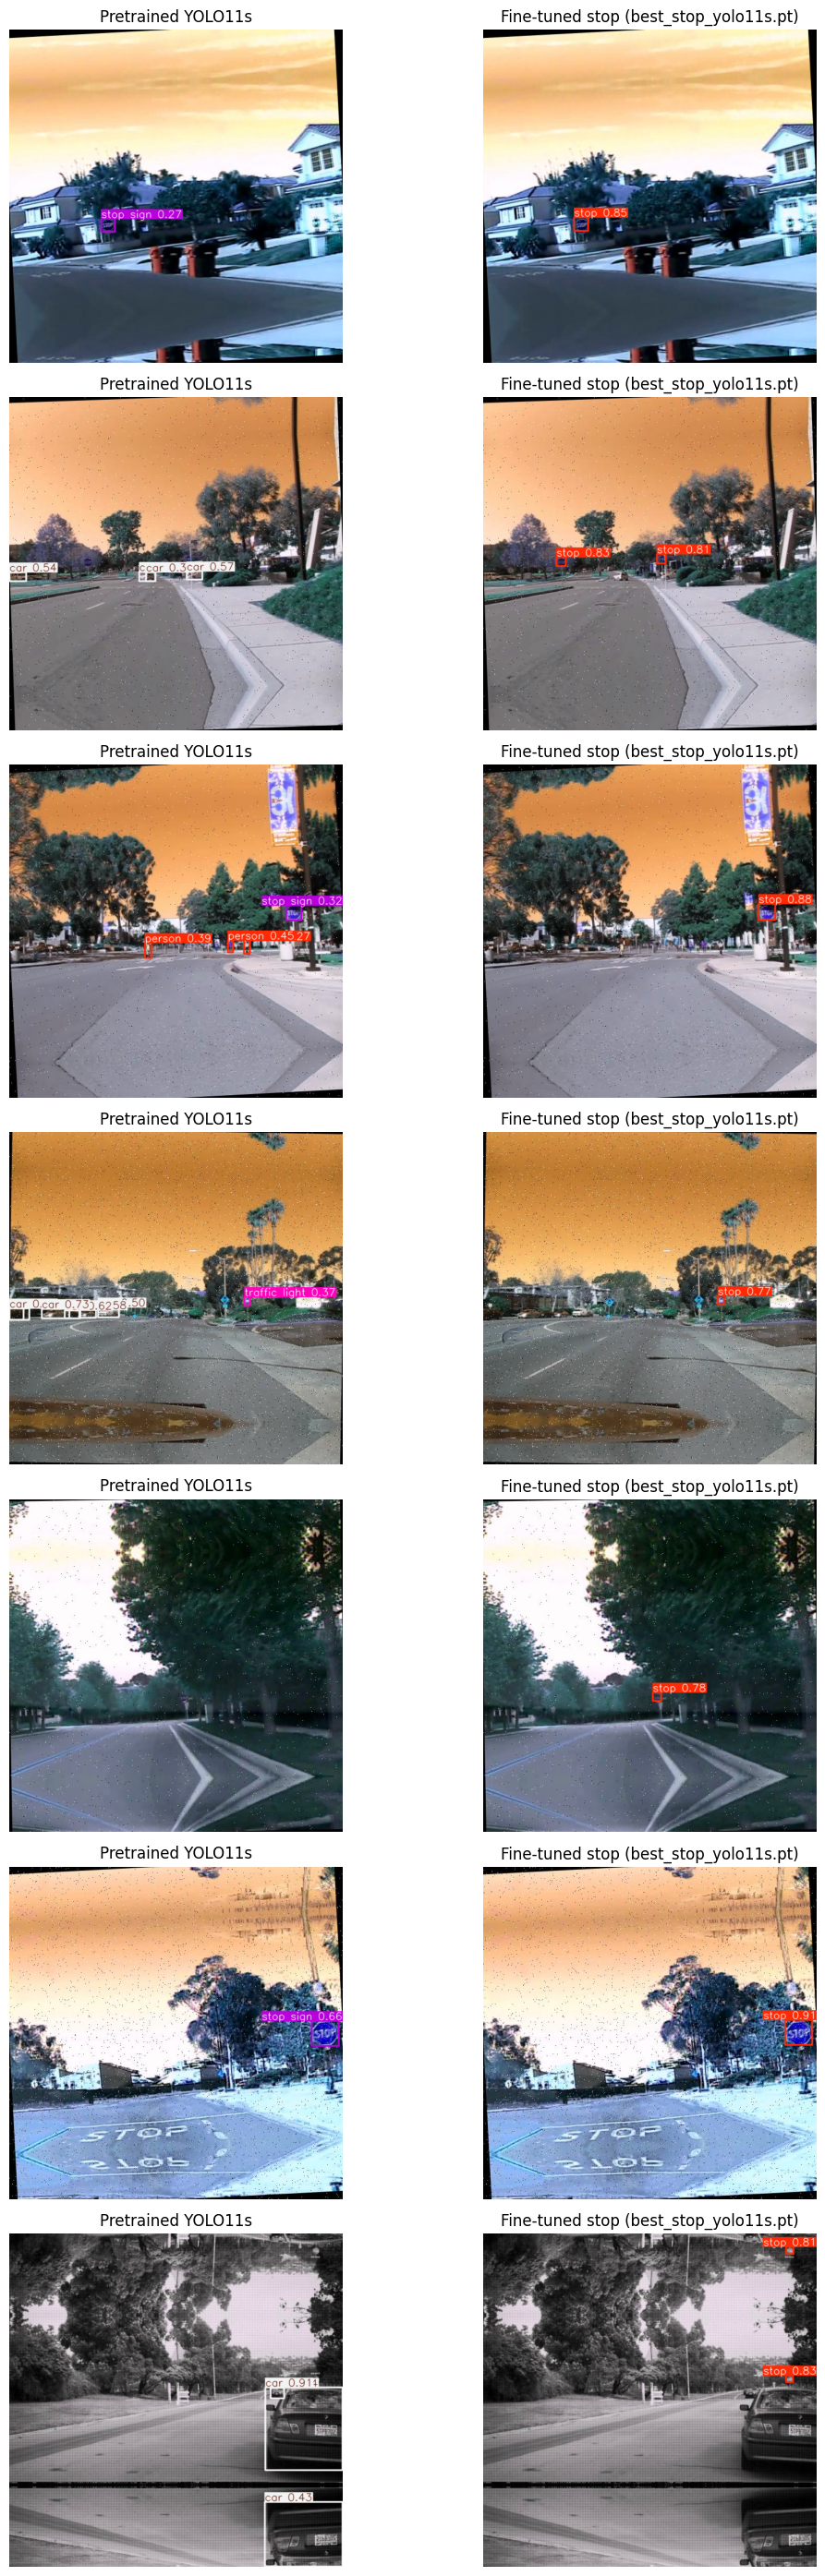

In [18]:
# Models
pretrained = YOLO("yolo11s.pt")
finetuned = YOLO("runs/detect/lisa_stop_yolo11s_fineTuned/weights/best.pt")  # your trained weights  # your trained weights

# Random test images (run config + split cells first)
test_dir = cat_split / "test" / "images"
imgs = list(test_dir.glob("*"))
random.shuffle(imgs)
imgs = imgs[:7]

fig, axes = plt.subplots(len(imgs), 2, figsize=(12, 4 * len(imgs)))
if len(imgs) == 1:
    axes = axes.reshape(1, -1)

for i, img_path in enumerate(imgs):
    p = str(img_path)

    r_pre = pretrained(p)
    axes[i, 0].imshow(r_pre[0].plot())
    axes[i, 0].set_title("Pretrained YOLO11s")
    axes[i, 0].axis("off")

    r_ft = finetuned(p)
    axes[i, 1].imshow(r_ft[0].plot())
    axes[i, 1].set_title("Fine-tuned stop (best_stop_yolo11s.pt)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## Speed limit signs (YOLO11s multi-class **detection**)

This block is **appended only**; the stop-sign cells above are unchanged. Run **split (next cell) before training**.

**`combined/` stays unsplit:** Keep a single flat pool: `combined/images/` + `combined/labels/`. It does **not** need `train/` or `val/` subfolders. The next cell **copies** stratified splits into **`speedlimit_yolo_split/`** (`train/`, `val/`, `test/` each with `images/` + `labels/`) and writes `speedlimit_yolo_split/dataset.yaml` for Ultralytics.

**`combined/` vs `speedlimit_Classified/`:** Use **`combined/`** as the training source (consistent class ids 0–13). `speedlimit_Classified/` is optional (per-class folders for inspection).

**Stratified split:** Stratify on the **first** bbox class in each label file. Split is **per class** with fixed ratios; very small classes may have no val images.

In [ ]:
# --- Speed limit ONLY: stratified train/val/test (run before training cells below) ---
# Reads flat combined/images + combined/labels. Writes splits under speedlimit_yolo_split/
# (does not modify combined/). Uses names/nc from combined/data.yaml.
import re

SEED_SL = 42
random.seed(SEED_SL)

PROJECT_ROOT_SL = Path.cwd().resolve()
SPEED_SOURCE = PROJECT_ROOT_SL / "combined"
SPEED_SPLIT = PROJECT_ROOT_SL / "speedlimit_yolo_split"
SPEED_DATA_YAML = SPEED_SPLIT / "dataset.yaml"
REF_DATA_YAML = SPEED_SOURCE / "data.yaml"

SPEED_MODEL_NAME = "yolo11s.pt"
SPEED_RUNS_DETECT = PROJECT_ROOT_SL / "runs" / "detect"

SPEED_TRAIN_RATIO = 0.75
SPEED_VAL_RATIO = 0.10
SPEED_TEST_RATIO = 0.15


def load_names_and_nc(yaml_path: Path) -> tuple[int, list[str]]:
    text = yaml_path.read_text(encoding="utf-8")
    m_nc = re.search(r"^nc:\s*(\d+)", text, re.M)
    nc = int(m_nc.group(1)) if m_nc else 14
    # lines like:   - "10 MPH"
    names = re.findall(r'^\s*-\s*"(.+)"\s*$', text, re.M)
    if len(names) != nc:
        print(f"Warning: parsed {len(names)} name entries, nc={nc} — check {yaml_path}")
    return nc, names


def get_labeled_samples_with_class(img_dir: Path, lbl_dir: Path) -> tuple[list, list[int]]:
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    samples: list = []
    classes: list[int] = []
    for img_path in sorted(img_dir.iterdir()):
        if not img_path.is_file() or img_path.suffix.lower() not in valid_exts:
            continue
        label_path = lbl_dir / f"{img_path.stem}.txt"
        if not label_path.is_file():
            continue
        lines = [
            ln
            for ln in label_path.read_text(encoding="utf-8", errors="ignore").splitlines()
            if ln.strip()
        ]
        if not lines:
            continue
        cid = int(lines[0].split()[0])
        samples.append((img_path, label_path))
        classes.append(cid)
    if not samples:
        raise RuntimeError("No labeled samples in combined/images + combined/labels")
    return samples, classes


def _alloc_per_class(n: int, tr: float, va: float, te: float) -> tuple[int, int, int]:
    """Per-class sample counts; always sum to n. Favors keeping >=1 train image when n>=1."""
    if n <= 0:
        return 0, 0, 0
    if n == 1:
        return 1, 0, 0
    n_tr = int(n * tr)
    n_va = int(n * va)
    n_te = n - n_tr - n_va
    # If val ratio > 0 but floor gave 0, take 1 from train (never take the only training image when test exists)
    if va > 0 and n_va == 0 and n >= 2 and n_tr > 1:
        if n_te > 0:
            n_tr -= 1
            n_va = 1
        else:
            n_tr -= 1
            n_va = 1
    n_te = n - n_tr - n_va
    # If test ratio > 0 but 0 test images, take 1 from train or val
    if te > 0 and n_te == 0 and n >= 2:
        if n_tr > 1:
            n_tr -= 1
        elif n_va > 1:
            n_va -= 1
    n_te = n - n_tr - n_va
    return n_tr, n_va, n_te


def stratified_by_class(
    samples: list, classes: list[int], tr: float, va: float, te: float, seed: int
) -> tuple[list, list, list]:
    if abs(tr + va + te - 1.0) > 1e-6:
        raise ValueError("train/val/test ratios must sum to 1")
    rng = random.Random(seed)
    from collections import defaultdict

    by_c: dict[int, list] = defaultdict(list)
    for s, c in zip(samples, classes, strict=True):
        by_c[c].append(s)

    train, val, test = [], [], []
    for c in sorted(by_c):
        items = by_c[c][:]
        rng.shuffle(items)
        n = len(items)
        n_tr, n_va, n_te = _alloc_per_class(n, tr, va, te)
        assert n_tr + n_va + n_te == n
        train += items[:n_tr]
        val += items[n_tr : n_tr + n_va]
        test += items[n_tr + n_va :]
    rng.shuffle(train)
    rng.shuffle(val)
    rng.shuffle(test)
    return train, val, test


def copy_split(split_name: str, split_samples: list, dest: Path) -> None:
    for img_path, lbl_path in split_samples:
        shutil.copy2(img_path, dest / split_name / "images" / img_path.name)
        shutil.copy2(lbl_path, dest / split_name / "labels" / lbl_path.name)


# --- run split ---
if not (SPEED_SOURCE / "images").is_dir() or not (SPEED_SOURCE / "labels").is_dir():
    raise FileNotFoundError("Expected combined/images and combined/labels")

nc_ref, class_names = load_names_and_nc(REF_DATA_YAML)
samples, y = get_labeled_samples_with_class(
    SPEED_SOURCE / "images", SPEED_SOURCE / "labels"
)
print(f"Loaded {len(samples)} image/label pairs; names nc={nc_ref} ({len(class_names)} entries)")

train_s, val_s, test_s = stratified_by_class(
    samples, y, SPEED_TRAIN_RATIO, SPEED_VAL_RATIO, SPEED_TEST_RATIO, SEED_SL
)
print(
    f"Stratified split: train={len(train_s)} val={len(val_s)} test={len(test_s)} "
    f"(~{SPEED_TRAIN_RATIO:.0%}/{SPEED_VAL_RATIO:.0%}/{SPEED_TEST_RATIO:.0%})"
)

# Per-class val counts (quick check rare classes are represented)
from collections import Counter

def split_class_counts(part: list) -> Counter:
    c = Counter()
    for _img, lp in part:
        lines = [ln for ln in lp.read_text().splitlines() if ln.strip()]
        if lines:
            c[int(lines[0].split()[0])] += 1
    return c

vc = split_class_counts(val_s)
print("Val: classes present:", sorted(vc), " min count in val:", min(vc.values()) if vc else 0)

if SPEED_SPLIT.exists():
    shutil.rmtree(SPEED_SPLIT)
for split in ("train", "val", "test"):
    (SPEED_SPLIT / split / "images").mkdir(parents=True, exist_ok=True)
    (SPEED_SPLIT / split / "labels").mkdir(parents=True, exist_ok=True)

for name, part in [("train", train_s), ("val", val_s), ("test", test_s)]:
    copy_split(name, part, SPEED_SPLIT)

names_block = "\n".join(f'  - "{n}"' for n in class_names)
dataset_text = f"""# Generated from combined/; stratified split.
path: {SPEED_SPLIT.resolve()}
train: train/images
val: val/images
test: test/images

nc: {nc_ref}
names:
{names_block}
"""
SPEED_DATA_YAML.write_text(dataset_text.strip() + "\n", encoding="utf-8")
print("Wrote", SPEED_DATA_YAML)

for sp in ("train", "val", "test"):
    n_img = len(list((SPEED_SPLIT / sp / "images").iterdir()))
    n_lbl = len(list((SPEED_SPLIT / sp / "labels").glob("*.txt")))
    print(f"{sp}: images={n_img} labels={n_lbl}")

In [ ]:
# Optional (speed limit): baseline val on test split - run split cell first
if not SPEED_DATA_YAML.is_file():
    raise FileNotFoundError(f"Run the split cell first; missing {SPEED_DATA_YAML}")
_pretrained_sl = YOLO(SPEED_MODEL_NAME)
_pre_sl = _pretrained_sl.val(
    data=str(SPEED_DATA_YAML),
    split="test",
    project=str(SPEED_RUNS_DETECT),
    name="speedlimit_pretrained_val_test",
)
print(
    f"Pretrained {SPEED_MODEL_NAME} on speed-limit test -> "
    f"mAP50={_pre_sl.box.map50:.4f}, mAP50-95={_pre_sl.box.map:.4f}"
)


In [ ]:
# Baseline predictions: draw predicted boxes on random test images
# (run the baseline-val cell first so _pretrained_sl and SPEED_SPLIT exist)
import cv2

_img_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
_test_img_dir = SPEED_SPLIT / "test" / "images"
sample_sl = [p for p in _test_img_dir.glob("*") if p.is_file() and p.suffix.lower() in _img_ext]
random.shuffle(sample_sl)
sample_sl = sample_sl[:6]
print(f"Showing {len(sample_sl)} test images from {_test_img_dir}")

if sample_sl:
    preds_sl = _pretrained_sl.predict(
        [str(p) for p in sample_sl],
        conf=0.25,
        verbose=False,
    )
    n = len(preds_sl)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < n:
            # plot() returns a BGR uint8 array; convert for matplotlib
            bgr = preds_sl[i].plot()
            ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
            nboxes = 0 if preds_sl[i].boxes is None else len(preds_sl[i].boxes)
            ax.set_title(f"{sample_sl[i].name} (boxes={nboxes})", fontsize=9)
        ax.axis("off")
    fig.suptitle("Baseline pretrained - predicted boxes on test images", fontsize=11)
    fig.tight_layout()
    plt.show()
else:
    print("No images under test/images to visualize.")


In [ ]:
# Fine-tune YOLO11s on speed-limit split (run stratified split cell first)
if not SPEED_DATA_YAML.is_file():
    raise FileNotFoundError(f"Run the split cell first; missing {SPEED_DATA_YAML}")
model_sl = YOLO(SPEED_MODEL_NAME)
results_sl = model_sl.train(
    data=str(SPEED_DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    patience=25,
    project=str(SPEED_RUNS_DETECT),
    name="speedlimit_yolo11s",
)
best_sl = Path(results_sl.save_dir) / "weights" / "best.pt"
print("Best weights:", best_sl)

In [ ]:
# Fine-tuned predictions: test metrics + boxes drawn on random test images
# (run the fine-tune cell above first so best_sl is defined)
import cv2

finetuned_sl = YOLO(str(best_sl))
_post_sl = finetuned_sl.val(
    data=str(SPEED_DATA_YAML),
    split="test",
    project=str(SPEED_RUNS_DETECT),
    name="speedlimit_finetuned_val_test",
)
print(
    f"Fine-tuned best.pt on speed-limit test -> "
    f"mAP50={_post_sl.box.map50:.4f}, mAP50-95={_post_sl.box.map:.4f}"
)

_img_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
_test_img_dir = SPEED_SPLIT / "test" / "images"
sample_ft = [p for p in _test_img_dir.glob("*") if p.is_file() and p.suffix.lower() in _img_ext]
random.shuffle(sample_ft)
sample_ft = sample_ft[:6]
print(f"Showing {len(sample_ft)} test images from {_test_img_dir}")

if sample_ft:
    preds_ft = finetuned_sl.predict(
        [str(p) for p in sample_ft],
        conf=0.25,
        verbose=False,
    )
    n = len(preds_ft)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < n:
            bgr = preds_ft[i].plot()
            ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
            nboxes = 0 if preds_ft[i].boxes is None else len(preds_ft[i].boxes)
            ax.set_title(f"{sample_ft[i].name} (boxes={nboxes})", fontsize=9)
        ax.axis("off")
    fig.suptitle("Fine-tuned best.pt - predicted boxes on test images", fontsize=11)
    fig.tight_layout()
    plt.show()
else:
    print("No images under test/images to visualize.")
